## Coherence Score

This notebook evaluates topic numbers ranging from 1-20 to find the optimal number of topics to be used for LDA topic modelling.



In [1]:
!pip install -r ../requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 2.8 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [2]:
# Imports 
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from gensim.models.coherencemodel import CoherenceModel

In [3]:
# Data Loading

CS_FILE            = Path("../data/skills/cs_special_course_skills.jsonl")
DATA_SCIENCE_FILE  = Path("../data/skills/data_science_jobs_skills.jsonl")

for f in [CS_FILE, DATA_SCIENCE_FILE]:
    if not f.exists():
        raise FileNotFoundError(f"{f} not found.")

cs_df            = pd.read_json(CS_FILE, lines=True)
data_science_df  = pd.read_json(DATA_SCIENCE_FILE, lines=True)

In [4]:
# Function to normalize multi-word skills by replacing spaces with underscores

def normalize_multiword_skills(skills):
    if not isinstance(skills, list):
        return []
    return [str(skill).strip().replace(" ", "_") for skill in skills if str(skill).strip()]

cs_df["skills"]            = cs_df["skills"].apply(normalize_multiword_skills)
data_science_df["skills"]  = data_science_df["skills"].apply(normalize_multiword_skills)

cs_texts            = cs_df["skills"].tolist()
data_science_texts  = data_science_df["skills"].tolist()

In [5]:
# Function to remove thematic area names from the skill lists to prevent them from dominating the topic modeling results
def clean_tokens(tokens):
    return [
        t for t in tokens
        if t not in {"computer_science", "information_technology"}
    ]

cs_texts            = [clean_tokens(t) for t in cs_texts]
data_science_texts  = [clean_tokens(t) for t in data_science_texts]

In [6]:
# Verifying the cleaned DataFrames

cs_df.head()
data_science_df.head()

,source,region,job_category,search_term,job_title,skills
0,workopolis,Canada,AI,Data Scientist,Junior Data Scientist,"[machine_learning, algorithms, banking, numpy,..."
1,workopolis,Canada,AI,Data Scientist,Data Scientist II,"[artificial_intelligence, data_engineers, data..."
2,workopolis,Canada,AI,Data Scientist,Data scientist,"[data_extraction, machine_learning, management..."
3,workopolis,Canada,AI,Data Scientist,Data Scientist,"[anomaly_detection, big_data, communication_st..."
4,workopolis,Canada,AI,Data Scientist,Data Analyst,"[anomaly_detection, big_data, data_analysis, d..."


In [7]:
# Function to evaluate coherence scores for a range of topic numbers and return the best model and its details
def evaluate_coherence(skills, start=1, limit=20, step=1, no_below=1, no_above=0.8):
    dictionary = Dictionary(skills)
    dictionary.filter_extremes(no_below=no_below, no_above=no_above)

    corpus = [dictionary.doc2bow(skill) for skill in skills]

    model_list = []
    coherence_values = []
    topic_range = list(range(start, limit, step))

    for num_topics in topic_range:
        model = LdaModel(
            corpus=corpus,
            id2word=dictionary,
            num_topics=num_topics,
            random_state=42,
            passes=10,
            iterations=100
        )

        coherence_model = CoherenceModel(
            model=model,
            texts=skills,
            dictionary=dictionary,
            coherence="c_v"
        )

        model_list.append(model)
        coherence_values.append(coherence_model.get_coherence())

    best_index = coherence_values.index(max(coherence_values))

    return {
        "dictionary": dictionary,
        "corpus": corpus,
        "topic_range": topic_range,
        "model_list": model_list,
        "coherence_values": coherence_values,
        "best_model": model_list[best_index],
        "best_num_topics": topic_range[best_index],
        "best_coherence": coherence_values[best_index],
    }


# Computer Science Course Topic Evaluation


Computer Science Course Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.2625
Number of Topics: 2, Coherence Score: 0.2735
Number of Topics: 3, Coherence Score: 0.3459
Number of Topics: 4, Coherence Score: 0.4301
Number of Topics: 5, Coherence Score: 0.3566
Number of Topics: 6, Coherence Score: 0.4104
Number of Topics: 7, Coherence Score: 0.3951
Number of Topics: 8, Coherence Score: 0.5037
Number of Topics: 9, Coherence Score: 0.4544
Number of Topics: 10, Coherence Score: 0.4697
Number of Topics: 11, Coherence Score: 0.4952
Number of Topics: 12, Coherence Score: 0.6204
Number of Topics: 13, Coherence Score: 0.6771
Number of Topics: 14, Coherence Score: 0.6767
Number of Topics: 15, Coherence Score: 0.6896
Number of Topics: 16, Coherence Score: 0.7208
Number of Topics: 17, Coherence Score: 0.7334
Number of Topics: 18, Coherence Score: 0.7720
Number of Topics: 19, Coherence Score: 0.6624


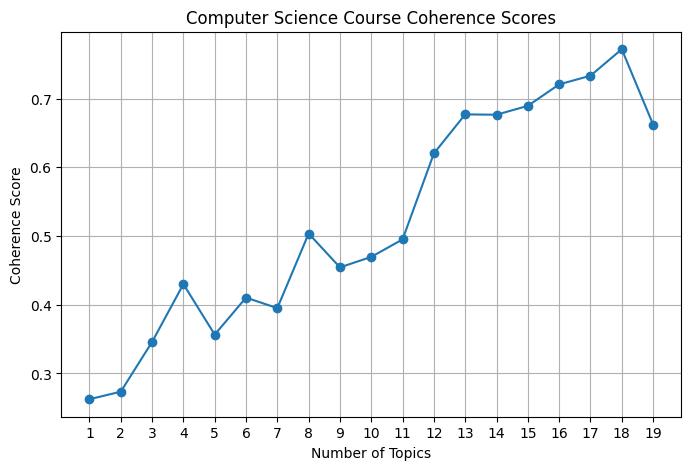

Optimal Number of Topics: 18
Coherence Score: 0.7720

Top 10 Words per Topic 18: 

Topic: 0: 0.011*"mathematical_models" + 0.011*"regular_expression" + 0.011*"computation_continuously" + 0.011*"np_completeness" + 0.011*"ture_machine" + 0.011*"quantum_computers" + 0.011*"abstractions" + 0.011*"underscores" + 0.011*"np_complete" + 0.011*"pdas" + 0.011*"finite_state_machine" + 0.011*"grammar_generate" + 0.011*"solve_complex" + 0.011*"basic_skills" + 0.011*"state_machine" + 0.011*"finite_automata" + 0.011*"nfas" + 0.011*"based_models" + 0.001*"diagrams" + 0.001*"manage_information"

Topic: 1: 0.011*"teamwork" + 0.011*"machine_learn" + 0.011*"algorithm_design" + 0.011*"problem_solve" + 0.011*"artificial_intelligence" + 0.011*"analytics" + 0.011*"study_design" + 0.011*"technology_planning" + 0.011*"field_research" + 0.011*"programs_computer" + 0.011*"apply_research" + 0.011*"computer_assisted" + 0.011*"cloud_development" + 0.011*"speech_synthesis" + 0.011*"planning_development" + 0.011*"imag

In [8]:
cs_results = evaluate_coherence(cs_texts, start=1, limit=20, step=1)

print("Computer Science Course Coherence Scores: ")
for k, score in zip(cs_results["topic_range"], cs_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(cs_results["topic_range"], cs_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Computer Science Course Coherence Scores")
plt.xticks(cs_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {cs_results['best_num_topics']}")
print(f"Coherence Score: {cs_results['best_coherence']:.4f}")
topics = cs_results["best_model"].print_topics(num_words=20)
print(f"\nTop 10 Words per Topic {cs_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")


# Data Science Jobs Topic Evaluation

Data Science Jobs Coherence Scores: 
Number of Topics: 1, Coherence Score: 0.3409
Number of Topics: 2, Coherence Score: 0.3200
Number of Topics: 3, Coherence Score: 0.3775
Number of Topics: 4, Coherence Score: 0.3192
Number of Topics: 5, Coherence Score: 0.3426
Number of Topics: 6, Coherence Score: 0.3644
Number of Topics: 7, Coherence Score: 0.3647
Number of Topics: 8, Coherence Score: 0.4047
Number of Topics: 9, Coherence Score: 0.4222
Number of Topics: 10, Coherence Score: 0.3575
Number of Topics: 11, Coherence Score: 0.3655
Number of Topics: 12, Coherence Score: 0.3804
Number of Topics: 13, Coherence Score: 0.4316
Number of Topics: 14, Coherence Score: 0.4216
Number of Topics: 15, Coherence Score: 0.3961
Number of Topics: 16, Coherence Score: 0.4861
Number of Topics: 17, Coherence Score: 0.4682
Number of Topics: 18, Coherence Score: 0.4987
Number of Topics: 19, Coherence Score: 0.5641


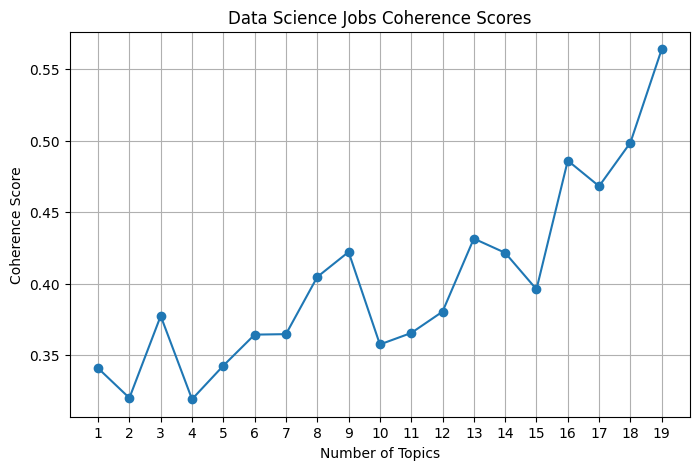

Optimal Number of Topics: 19
Coherence Score: 0.5641

Top 10 Words per Topic 19: 

Topic: 0: 0.045*"tooling" + 0.045*"python" + 0.031*"software_engineering" + 0.031*"crm" + 0.031*"machine_learning" + 0.031*"curiosity" + 0.031*"reliability" + 0.031*"gcp" + 0.016*"tensorflow" + 0.016*"framing"

Topic: 1: 0.065*"software_engineering" + 0.045*"curiosity" + 0.045*"python" + 0.023*"forecasting" + 0.023*"scikit_learn" + 0.023*"sagemaker" + 0.023*"data_engineering" + 0.023*"pytorch" + 0.023*"computer_vision" + 0.023*"tensorflow"

Topic: 2: 0.048*"curiosity" + 0.048*"emerging_technology" + 0.048*"solving_problems" + 0.048*"tooling" + 0.048*"prototype" + 0.048*"emerging_technologies" + 0.048*"software_engineering" + 0.048*"typescript" + 0.048*"stakeholder_engagement" + 0.048*"devops"

Topic: 3: 0.054*"git" + 0.054*"python" + 0.045*"machine_learning" + 0.036*"version_control" + 0.036*"sql" + 0.027*"track" + 0.027*"data_pipelines" + 0.018*"artificial_intelligence" + 0.018*"writing" + 0.018*"mathem

In [9]:
data_science_results = evaluate_coherence(data_science_texts, start=1, limit=20, step=1)

print("Data Science Jobs Coherence Scores: ")
for k, score in zip(data_science_results["topic_range"], data_science_results["coherence_values"]):
    print(f"Number of Topics: {k}, Coherence Score: {score:.4f}")


plt.figure(figsize=(8, 5))
plt.plot(data_science_results["topic_range"], data_science_results["coherence_values"], marker="o")
plt.xlabel("Number of Topics")
plt.ylabel("Coherence Score")
plt.title("Data Science Jobs Coherence Scores")
plt.xticks(data_science_results["topic_range"])
plt.grid(True)
plt.show()

print(f"Optimal Number of Topics: {data_science_results['best_num_topics']}")
print(f"Coherence Score: {data_science_results['best_coherence']:.4f}")
topics = data_science_results["best_model"].print_topics(num_words=10)
print(f"\nTop 10 Words per Topic {data_science_results['best_num_topics']}: ")
for topic_num, topic_words in topics:
    print(f"\nTopic: {topic_num}: {topic_words}")